# **APRENDIZAGEM NÃO SUPERVISIONADA: AGRUPAMENTO**

Este projeto tem por objetivo desenvolver um algoritmo de Machine Learning para agrupar clientes de um shopping.

Os dados foram extraídos do site do Kaggle:

https://www.kaggle.com/shwetabh123/mall-customers

**IMPORTANDO BIBLIOTECAS**

In [ ]:
import numpy as np
import pandas as pd
import warnings
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import MeanShift
from kmodes.kprototypes import KPrototypes
warnings.filterwarnings("ignore")


**CARREGANDO OS DADOS**

In [ ]:
df = pd.read_csv('/home/mau/Desktop/ML_Luciano-Galdino/7-Agrupamento/Dados/Mall_Customers.csv',
                    sep=',', encoding='iso-8859-1')

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**ATRIBUTOS:**

CustomerID: identificação do cliente.

Genre: Gênero.

Age: idade.

Annual Income (k$):	Rendimento anual.

Spending Score (1 a 100): Pontuação de gastos.

**IDADE**

In [ ]:
hist =  px.histogram (df,  x = "Age", nbins=60)
hist.update_layout(width=600,height=400,title_text='Distribuição das idades')
hist.show()

**GÊNERO**

In [ ]:
df['Genre'].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

In [ ]:
df['Spending Score (1-100)'].value_counts()

Spending Score (1-100)
42    8
55    7
73    6
46    6
48    5
     ..
68    1
85    1
23    1
8     1
18    1
Name: count, Length: 84, dtype: int64

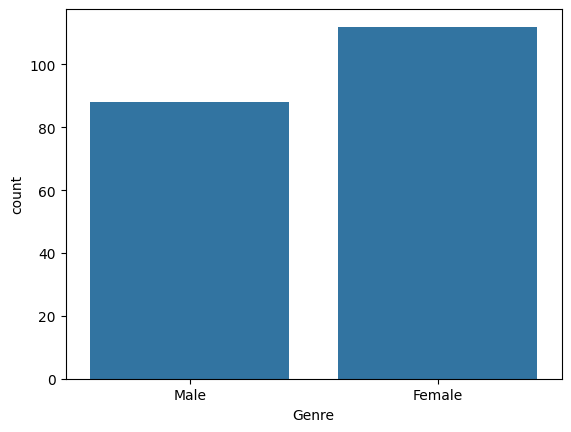

In [ ]:
sns.countplot(x='Genre', data=df);

## **EXPLORAÇÃO E TRATAMENTO DOS DADOS**

**Alterando nomes das colunas**

In [ ]:
df.head(2)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81


In [ ]:
df.rename(columns={'CustomerID': 'identificacao'}, inplace=True)
df.rename(columns={'Genre': 'genero'}, inplace=True)
df.rename(columns={'Age': 'idade'}, inplace=True)
df.rename(columns={'Annual Income (k$)': 'rendimento','Spending Score (1-100)':'pontuacao'}, inplace=True)

In [ ]:
df.head(3)

,identificacao,genero,idade,rendimento,pontuacao
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


**Valores Missing (NAN)**

In [ ]:
# RELAÇÃO DA QUANTIDADE
df.isnull().sum()

identificacao    0
genero           0
idade            0
rendimento       0
pontuacao        0
dtype: int64

**Análise dos tipos de atributos.**

In [ ]:
# object: strings
# int64: inteiros
# float64: reais
# complex: complexos
df.dtypes

identificacao     int64
genero           object
idade             int64
rendimento        int64
pontuacao         int64
dtype: object

**Dados Estatísticos**

In [ ]:
df.describe()

,identificacao,idade,rendimento,pontuacao
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


**Análise dos outliers**

**Rendimento**

In [ ]:
boxplot = px.box(df, y="rendimento")
boxplot.show()

**Idade**

In [ ]:
boxplot = px.box(df, y="idade")
boxplot.show()

**Pontuação**

In [ ]:
boxplot = px.box(df, y="pontuacao")
boxplot.show()

## **PRÉ-PROCESSAMENTO**

In [ ]:
df.head(2)

,identificacao,genero,idade,rendimento,pontuacao
0,1,Male,19,15,39
1,2,Male,21,15,81


**Excluir identificação do cliente**

In [ ]:
df2 = df.drop(labels = 'identificacao', axis = 1)

In [ ]:
df2.head(2)

,genero,idade,rendimento,pontuacao
0,Male,19,15,39
1,Male,21,15,81


**Transformar variáveis categóricas em numéricas**

In [ ]:
df2['genero'].replace({'Female': 0, 'Male': 1}, inplace=True)

In [ ]:
df2.head(3)

,genero,idade,rendimento,pontuacao
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6


**Escalonamento (Padronização)**

In [ ]:
escala = StandardScaler()
df2_esc = escala.fit_transform(df2)

In [ ]:
df2_esc

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

## **K-MEANS COM DOIS ATRIBUTOS (Sem Padronizar)**

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html

In [ ]:
df2

,genero,idade,rendimento,pontuacao
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [ ]:
dados = df2.iloc[:, [2,3]].values

In [ ]:
dados

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

**Elbow Method**

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 5, max_iter = 300)
    kmeans.fit(dados)
    
    # inertia: Método para gerar o wcss
    wcss.append(kmeans.inertia_)

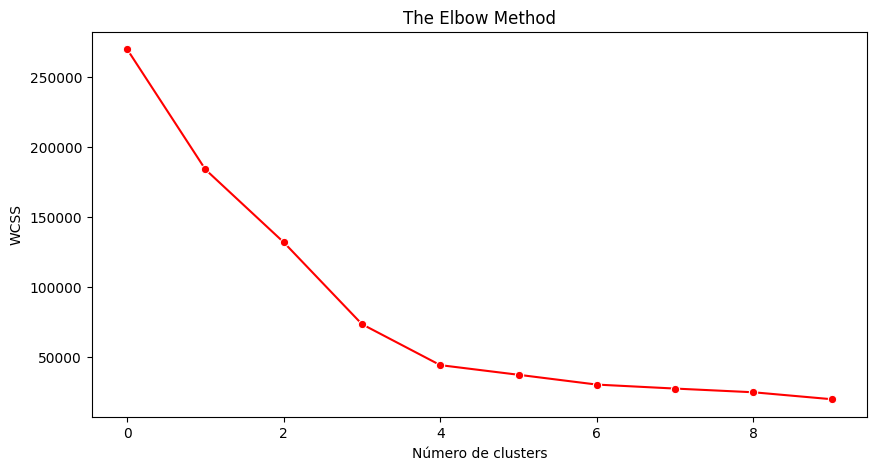

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(wcss,marker='o',color='red')
plt.title('The Elbow Method')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS');

**Agrupamento**

In [ ]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 5, max_iter = 300)


In [ ]:
kmeans1 = kmeans.fit(dados)

In [ ]:
# Coordenadas dos Centróides
centroides = kmeans1.cluster_centers_
centroides

array([[26.30434783, 20.91304348],
       [48.26      , 56.48      ],
       [87.        , 18.63157895],
       [86.53846154, 82.12820513]])

In [ ]:
# Classificação dos dados
classificacao = kmeans1.labels_
classificacao

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3], dtype=int32)

In [ ]:
dados[3,:]

array([16, 77])

In [ ]:
classificacao[3]

np.int32(1)

In [ ]:
graf1 = px.scatter(x = dados[:,0], y = dados[:,1], color=classificacao)
graf2 = px.scatter(x = centroides[:,0], y = centroides[:,1], size = [15, 15, 15, 15])
graf3 = go.Figure(data = graf1.data + graf2.data)
graf3.update_layout(width=800,height=500,title_text='Agrupamento K-Means')
graf3.update_xaxes(title = 'Rendimento anual (K$)')
graf3.update_yaxes(title = 'Pontuação')
graf3.show()

In [ ]:
agrupamento = pd.DataFrame(classificacao, columns = ['Grupo'])
agrupamento

,Grupo
0,0
1,1
2,0
3,1
4,0
...,...
195,3
196,2
197,3
198,2


In [ ]:
df3 = pd.concat([df, agrupamento],axis=1)
df3

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,0
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,3
196,197,Female,45,126,28,2
197,198,Male,32,126,74,3
198,199,Male,32,137,18,2


In [ ]:
df3.iloc[150 , :]

identificacao     151
genero           Male
idade              43
rendimento         78
pontuacao          17
Grupo               2
Name: 150, dtype: object

In [ ]:
df3.loc[df3.identificacao == 92]

,identificacao,genero,idade,rendimento,pontuacao,Grupo
91,92,Male,18,59,41,1


In [ ]:
grupo0 = df3.loc[df3.Grupo == 0]
grupo0

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,0
2,3,Female,20,16,6,0
4,5,Female,31,17,40,0
6,7,Female,35,18,6,0
8,9,Male,64,19,3,0
10,11,Male,67,19,14,0
12,13,Female,58,20,15,0
14,15,Male,37,20,13,0
16,17,Female,35,21,35,0
18,19,Male,52,23,29,0


In [ ]:
grupo0.shape

(23, 6)

In [ ]:
grupo1 = df3.loc[df3.Grupo == 1]
grupo1

,identificacao,genero,idade,rendimento,pontuacao,Grupo
1,2,Male,21,15,81,1
3,4,Female,23,16,77,1
5,6,Female,22,17,76,1
7,8,Female,23,18,94,1
9,10,Female,30,19,72,1
...,...,...,...,...,...,...
118,119,Female,51,67,43,1
119,120,Female,50,67,57,1
120,121,Male,27,67,56,1
121,122,Female,38,67,40,1


In [ ]:
grupo1.shape

(100, 6)

## **K-MEANS COM TODOS ATRIBUTOS**

In [ ]:
df2_esc

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

In [ ]:
df2_esc.shape

(200, 4)

**Elbow Method**

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,15):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 5, max_iter = 300)
    kmeans.fit(df2_esc)
    
# Método inertia para gerar o wcss
    wcss.append(kmeans.inertia_)

Text(0, 0.5, 'WCSS')

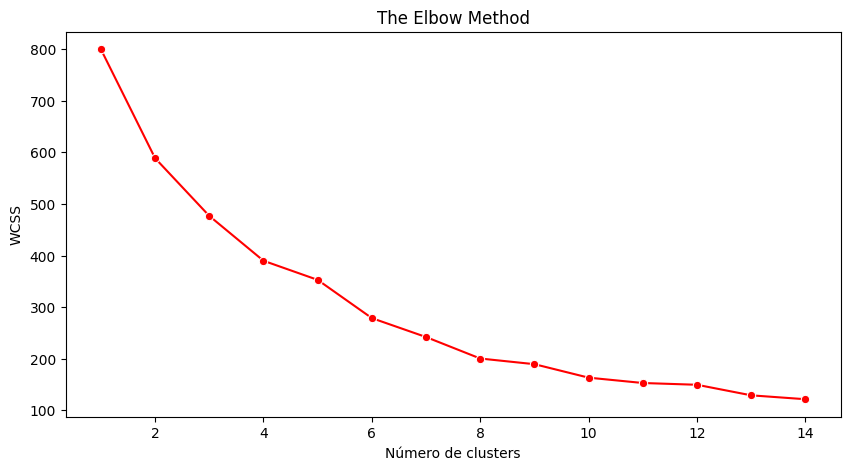

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x=range(1, 15), y=wcss, marker='o',color='red')
plt.title('The Elbow Method')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')

**Agrupamento**

In [ ]:
kmeans = KMeans(n_clusters = 6, init = 'k-means++', random_state = 5, max_iter = 300)


In [ ]:
kmeans2 = kmeans.fit(df2_esc)

In [ ]:
# Coordenadas dos Centróides
centroides = kmeans2.cluster_centers_
centroides

array([[-0.88640526,  0.70849671, -0.00229017, -0.56133101],
       [ 0.04339047, -0.44191719,  0.99158305,  1.23950275],
       [ 1.12815215,  1.33075947, -0.48486081, -0.42786906],
       [ 1.12815215, -1.02205127, -0.75821082,  0.43783969],
       [ 1.12815215, -0.02700694,  0.96701244, -1.39716754],
       [-0.88640526, -0.92608124, -0.70017176,  0.28182355]])

In [ ]:
# Inversão do escalonamento
escala.inverse_transform(kmeans2.cluster_centers_)

array([[-2.77555756e-16,  4.87222222e+01,  6.05000000e+01,
         3.57407407e+01],
       [ 4.61538462e-01,  3.26923077e+01,  8.65384615e+01,
         8.21282051e+01],
       [ 1.00000000e+00,  5.73928571e+01,  4.78571429e+01,
         3.91785714e+01],
       [ 1.00000000e+00,  2.46086957e+01,  4.06956522e+01,
         6.14782609e+01],
       [ 1.00000000e+00,  3.84736842e+01,  8.58947368e+01,
         1.42105263e+01],
       [ 1.66533454e-16,  2.59459459e+01,  4.22162162e+01,
         5.74594595e+01]])

In [ ]:
# Classificação dos dados
classificacao2 = kmeans2.labels_
classificacao2

array([3, 3, 5, 5, 5, 5, 0, 5, 2, 5, 2, 5, 0, 5, 2, 3, 5, 3, 2, 5, 3, 3,
       0, 3, 0, 3, 0, 3, 0, 5, 2, 5, 2, 3, 0, 5, 0, 5, 0, 5, 0, 3, 2, 5,
       0, 5, 0, 5, 5, 5, 0, 3, 5, 2, 0, 2, 0, 2, 5, 2, 2, 3, 0, 0, 2, 3,
       0, 0, 3, 5, 2, 0, 0, 0, 2, 3, 0, 2, 5, 0, 2, 3, 2, 0, 5, 2, 0, 5,
       5, 0, 0, 3, 2, 0, 5, 3, 0, 5, 2, 3, 5, 0, 2, 3, 2, 5, 0, 2, 2, 2,
       2, 5, 0, 3, 5, 5, 0, 0, 0, 0, 3, 0, 0, 1, 5, 1, 4, 1, 2, 1, 4, 1,
       5, 1, 4, 1, 0, 1, 4, 1, 0, 1, 5, 1, 4, 1, 4, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 4, 1, 0, 1, 4, 1, 4, 1, 4, 1, 0, 1, 4, 1, 4, 1, 0, 1,
       4, 1, 4, 1, 0, 1, 4, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1, 0, 1,
       4, 1], dtype=int32)

In [ ]:
classificacao2[199]

np.int32(1)

In [ ]:
agrupamento2 = pd.DataFrame(classificacao2, columns = ['Grupo'])
agrupamento2

,Grupo
0,3
1,3
2,5
3,5
4,5
...,...
195,1
196,0
197,1
198,4


In [ ]:
df4 = pd.concat([df, agrupamento2],axis=1)
df4

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,3
1,2,Male,21,15,81,3
2,3,Female,20,16,6,5
3,4,Female,23,16,77,5
4,5,Female,31,17,40,5
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,0
197,198,Male,32,126,74,1
198,199,Male,32,137,18,4


In [ ]:
df4.iloc[125 , :]

identificacao       126
genero           Female
idade                31
rendimento           70
pontuacao            77
Grupo                 1
Name: 125, dtype: object

In [ ]:
df4.loc[df4.identificacao == 76]

,identificacao,genero,idade,rendimento,pontuacao,Grupo
75,76,Male,26,54,54,3


In [ ]:
grupo0 = df4.loc[df4.Grupo == 0]
grupo0

,identificacao,genero,idade,rendimento,pontuacao,Grupo
6,7,Female,35,18,6,0
12,13,Female,58,20,15,0
22,23,Female,46,25,5,0
24,25,Female,54,28,14,0
26,27,Female,45,28,32,0
28,29,Female,40,29,31,0
34,35,Female,49,33,14,0
36,37,Female,42,34,17,0
38,39,Female,36,37,26,0
40,41,Female,65,38,35,0


In [ ]:
grupo0.shape

(54, 6)

## **K-MEANS COM PCA**

In [ ]:
df2_esc

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

In [ ]:
df2_esc.shape

(200, 4)

**Componentes Principais**

In [ ]:
pca = PCA(n_components = 2)

In [ ]:
df2_pca = pca.fit_transform(df2_esc)

In [ ]:
df2_pca

array([[-4.06382715e-01, -5.20713635e-01],
       [-1.42767287e+00, -3.67310199e-01],
       [ 5.07605706e-02, -1.89406774e+00],
       [-1.69451310e+00, -1.63190805e+00],
       [-3.13108383e-01, -1.81048272e+00],
       [-1.71744627e+00, -1.59926418e+00],
       [ 7.90821124e-01, -1.94727112e+00],
       [-2.14832159e+00, -1.50537369e+00],
       [ 2.77428623e+00, -8.82987672e-01],
       [-1.21629477e+00, -1.61640464e+00],
       [ 2.62905084e+00, -8.61237043e-01],
       [-1.68947038e+00, -1.54542784e+00],
       [ 1.68582253e+00, -2.02394479e+00],
       [-1.64607339e+00, -1.52251259e+00],
       [ 1.17443628e+00, -6.12790961e-01],
       [-1.32613070e+00, -2.36719149e-01],
       [ 1.67728253e-02, -1.74344572e+00],
       [-1.07842454e+00, -2.44715641e-01],
       [ 1.48758780e+00, -5.72676028e-01],
       [-1.66373169e+00, -1.43259774e+00],
       [ 4.88090311e-01, -3.92921145e-01],
       [-1.01895051e+00, -1.66247511e-01],
       [ 1.35891492e+00, -1.82866936e+00],
       [-7.

In [ ]:
# razão das variáveis explicativas
pca.explained_variance_ratio_

array([0.33690046, 0.26230645])

In [ ]:
# Soma das variáveis explicativas
pca.explained_variance_ratio_.sum()

np.float64(0.5992069019819846)

**Elbow Method**

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 5, max_iter = 300)
    kmeans.fit(df2_pca)
# Método inertia para gerar o wcss
    wcss.append(kmeans.inertia_)

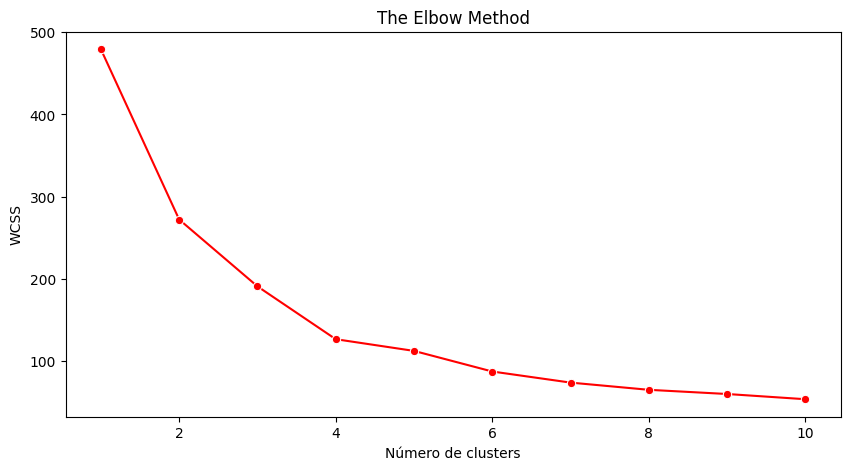

In [ ]:
plt.figure(figsize=(10,5))
sns.lineplot(x=range(1, 11), y=wcss,marker='o',color='red')
plt.title('The Elbow Method')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS');

**Agrupamento**

In [ ]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', random_state = 5, max_iter = 300)


In [ ]:
kmeans3 = kmeans.fit(df2_pca)

In [ ]:
# Coordenadas dos Centróides
centroides = kmeans3.cluster_centers_
centroides

array([[ 0.59773908, -1.02135332],
       [-0.89924813,  1.20707643],
       [ 1.23620204,  0.6001392 ],
       [-1.17272864, -0.50410113]])

In [ ]:
# Classificação dos dados
classificacao3 = kmeans3.labels_
classificacao3

array([3, 3, 0, 3, 0, 3, 0, 3, 2, 3, 2, 3, 0, 3, 0, 3, 0, 3, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 3, 0, 3, 2, 3, 2, 3, 0, 3, 0, 3, 0, 3, 0, 3, 2, 3,
       0, 3, 0, 3, 3, 0, 0, 1, 3, 2, 0, 2, 0, 2, 3, 2, 2, 1, 0, 0, 2, 1,
       0, 0, 1, 3, 2, 0, 0, 0, 2, 1, 0, 2, 3, 0, 2, 2, 2, 0, 3, 2, 0, 3,
       3, 0, 0, 1, 2, 0, 3, 1, 0, 3, 2, 1, 3, 0, 2, 1, 2, 3, 0, 2, 2, 2,
       2, 3, 0, 1, 3, 3, 0, 0, 0, 0, 1, 0, 3, 1, 3, 3, 2, 1, 2, 1, 2, 1,
       3, 3, 2, 3, 0, 1, 2, 3, 2, 1, 3, 3, 2, 1, 2, 3, 0, 1, 2, 1, 0, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [ ]:
classificacao3[2]

np.int32(0)

In [ ]:
graf1 = px.scatter(x = df2_pca[:,0], y = df2_pca[:,1], color=classificacao3)
graf2 = px.scatter(x = centroides[:,0], y = centroides[:,1], size = [15, 15, 15, 15])
graf3 = go.Figure(data = graf1.data + graf2.data)
graf3.update_layout(width=800,height=500,title_text='Agrupamento K-Means com PCA')
graf3.update_xaxes(title = 'Componente 1')
graf3.update_yaxes(title = 'Componente 2')
graf3.show()

In [ ]:
agrupamento3 = pd.DataFrame(classificacao3, columns = ['Grupo'])
agrupamento3

,Grupo
0,3
1,3
2,0
3,3
4,0
...,...
195,1
196,2
197,1
198,2


In [ ]:
df5 = pd.concat([df, agrupamento3],axis=1)
df5

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,3
1,2,Male,21,15,81,3
2,3,Female,20,16,6,0
3,4,Female,23,16,77,3
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,2
197,198,Male,32,126,74,1
198,199,Male,32,137,18,2


In [ ]:
df5.iloc[125 , :]

identificacao       126
genero           Female
idade                31
rendimento           70
pontuacao            77
Grupo                 3
Name: 125, dtype: object

In [ ]:
df5.loc[df5.identificacao == 76]

,identificacao,genero,idade,rendimento,pontuacao,Grupo
75,76,Male,26,54,54,1


In [ ]:
grupo0 = df5.loc[df5.Grupo == 0]
grupo0

,identificacao,genero,idade,rendimento,pontuacao,Grupo
2,3,Female,20,16,6,0
4,5,Female,31,17,40,0
6,7,Female,35,18,6,0
12,13,Female,58,20,15,0
14,15,Male,37,20,13,0
16,17,Female,35,21,35,0
18,19,Male,52,23,29,0
20,21,Male,35,24,35,0
22,23,Female,46,25,5,0
24,25,Female,54,28,14,0


In [ ]:
grupo0.shape

(48, 6)

## **ALGORITMO HIERÁRQUICO COM PCA**

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html

In [ ]:
df2.head()

,genero,idade,rendimento,pontuacao
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
df2_esc

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

In [ ]:
df2_esc.shape

(200, 4)

**Componentes Principais**

In [ ]:
pca = PCA(n_components = 2)

In [ ]:
df2_pca = pca.fit_transform(df2_esc)

In [ ]:
df2_pca

array([[-4.06382715e-01, -5.20713635e-01],
       [-1.42767287e+00, -3.67310199e-01],
       [ 5.07605706e-02, -1.89406774e+00],
       [-1.69451310e+00, -1.63190805e+00],
       [-3.13108383e-01, -1.81048272e+00],
       [-1.71744627e+00, -1.59926418e+00],
       [ 7.90821124e-01, -1.94727112e+00],
       [-2.14832159e+00, -1.50537369e+00],
       [ 2.77428623e+00, -8.82987672e-01],
       [-1.21629477e+00, -1.61640464e+00],
       [ 2.62905084e+00, -8.61237043e-01],
       [-1.68947038e+00, -1.54542784e+00],
       [ 1.68582253e+00, -2.02394479e+00],
       [-1.64607339e+00, -1.52251259e+00],
       [ 1.17443628e+00, -6.12790961e-01],
       [-1.32613070e+00, -2.36719149e-01],
       [ 1.67728253e-02, -1.74344572e+00],
       [-1.07842454e+00, -2.44715641e-01],
       [ 1.48758780e+00, -5.72676028e-01],
       [-1.66373169e+00, -1.43259774e+00],
       [ 4.88090311e-01, -3.92921145e-01],
       [-1.01895051e+00, -1.66247511e-01],
       [ 1.35891492e+00, -1.82866936e+00],
       [-7.

**Dendograma**

Single → liga pelos pontos mais próximos (cadeias).

Complete → liga pelos pontos mais distantes (clusters compactos).

Average → compromisso entre os dois.

Centroid → usa a média dos pontos.

Ward → minimiza variância, ótimo para grupos bem definidos.

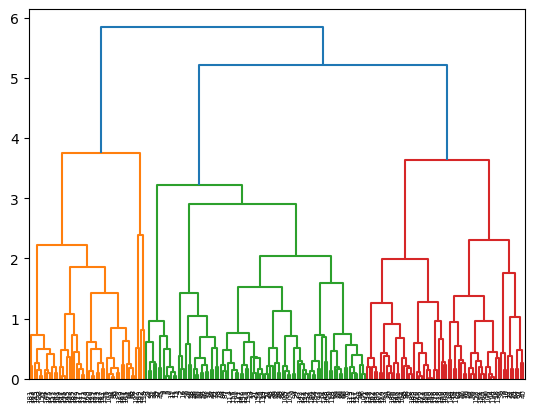

In [ ]:
dendrograma = dendrogram(linkage(df2_pca, method = 'complete'))

In [ ]:
hier = AgglomerativeClustering(n_clusters=3, metric = 'euclidean', linkage = 'complete')
classificacao4 = hier.fit_predict(df2_pca)

In [ ]:
classificacao4

array([2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 2, 2, 1, 2, 2, 2,
       1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 0, 1, 2, 2, 2, 2, 2, 1, 0, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 1, 0, 1, 2, 1, 0,
       2, 1, 0, 2, 1, 2, 2, 2, 1, 0, 2, 2, 2, 2, 1, 2, 1, 2, 2, 1, 2, 2,
       2, 2, 1, 0, 1, 2, 2, 0, 2, 2, 1, 0, 2, 2, 1, 0, 1, 2, 1, 1, 1, 1,
       1, 2, 2, 0, 2, 2, 1, 2, 2, 2, 0, 2, 2, 0, 2, 2, 1, 0, 1, 0, 1, 0,
       2, 2, 1, 0, 1, 0, 1, 2, 1, 0, 2, 0, 1, 0, 1, 2, 2, 0, 1, 0, 1, 2,
       1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 0, 1, 0, 2, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 2, 0, 1, 0, 2, 0, 1, 0, 1, 0, 2, 0, 0, 0, 1, 0, 1, 0,
       0, 0])

In [ ]:
graf = px.scatter(x = df2_pca[:,0], y = df2_pca[:,1], color=classificacao4)
graf.update_layout(width=800,height=500,title_text='Agrupamento Hierárquico')
graf.show()

**Agrupamento**

In [ ]:
agrupamento4 = pd.DataFrame(classificacao4, columns = ['Grupo'])
agrupamento4

,Grupo
0,2
1,2
2,2
3,2
4,2
...,...
195,0
196,1
197,0
198,0


In [ ]:
df6 = pd.concat([df, agrupamento4],axis=1)
df6

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,0
196,197,Female,45,126,28,1
197,198,Male,32,126,74,0
198,199,Male,32,137,18,0


In [ ]:
df6.loc[df6.identificacao == 22]

,identificacao,genero,idade,rendimento,pontuacao,Grupo
21,22,Male,25,24,73,2


In [ ]:
grupo2 = df6.loc[df6.Grupo == 2]
grupo2

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
159,160,Female,30,78,73,2
168,169,Female,36,87,27,2
180,181,Female,37,97,32,2
184,185,Female,41,99,39,2


## **ALGORITMO HIERÁRQUICO: todos atributos**






In [ ]:
df2.head()

,genero,idade,rendimento,pontuacao
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
df2_esc

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

In [ ]:
df2_esc.shape

(200, 4)

**Dendograma**

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

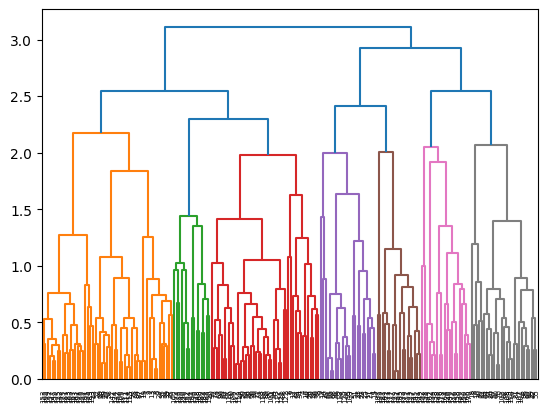

In [ ]:
dendrograma = dendrogram(linkage(df2_esc, method = 'average'))

In [ ]:
from sklearn.cluster import AgglomerativeClustering

In [ ]:
hier = AgglomerativeClustering(n_clusters=7, metric='euclidean', linkage = 'average')
classificacao5 = hier.fit_predict(df2_esc)

In [ ]:
classificacao5

array([5, 5, 4, 0, 4, 0, 4, 0, 1, 0, 1, 0, 4, 0, 5, 5, 4, 5, 1, 0, 5, 5,
       4, 5, 4, 5, 4, 5, 4, 0, 1, 0, 1, 5, 4, 0, 4, 0, 4, 0, 4, 5, 1, 0,
       4, 0, 4, 0, 0, 0, 4, 5, 0, 1, 4, 1, 4, 1, 0, 1, 1, 5, 4, 4, 1, 5,
       4, 4, 5, 0, 1, 4, 4, 4, 1, 5, 4, 1, 0, 4, 1, 1, 1, 4, 0, 1, 4, 0,
       4, 4, 4, 5, 1, 4, 4, 5, 4, 0, 1, 5, 0, 4, 1, 5, 1, 0, 4, 1, 1, 1,
       1, 0, 4, 5, 0, 0, 4, 4, 4, 4, 5, 4, 4, 2, 0, 0, 3, 2, 3, 2, 3, 2,
       0, 0, 3, 0, 6, 2, 3, 0, 6, 2, 0, 0, 3, 2, 3, 0, 6, 2, 3, 2, 6, 0,
       6, 0, 3, 0, 3, 0, 6, 0, 3, 0, 3, 0, 3, 0, 6, 2, 3, 2, 3, 2, 6, 0,
       3, 2, 3, 2, 6, 0, 3, 0, 6, 2, 6, 2, 6, 0, 6, 0, 3, 0, 6, 0, 6, 2,
       3, 2])

**Agrupamento**

In [ ]:
agrupamento5 = pd.DataFrame(classificacao5, columns = ['Grupo'])
agrupamento5

,Grupo
0,5
1,5
2,4
3,0
4,4
...,...
195,0
196,6
197,2
198,3


In [ ]:
df7 = pd.concat([df, agrupamento5],axis=1)
df7

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,5
1,2,Male,21,15,81,5
2,3,Female,20,16,6,4
3,4,Female,23,16,77,0
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,0
196,197,Female,45,126,28,6
197,198,Male,32,126,74,2
198,199,Male,32,137,18,3


In [ ]:
df7.loc[df7.identificacao == 131]

,identificacao,genero,idade,rendimento,pontuacao,Grupo
130,131,Male,47,71,9,3


In [ ]:
grupo4 = df7.loc[df7.Grupo == 6]
grupo4.head(2)

,identificacao,genero,idade,rendimento,pontuacao,Grupo
136,137,Female,44,73,7,6
140,141,Female,57,75,5,6


In [ ]:
grupo4.shape

(15, 6)

## **ALGORITMO DBSCAN COM PCA**

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

In [ ]:
df2_esc

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

In [ ]:
df2_esc.shape

(200, 4)

**Componentes Principais**

In [ ]:
pca = PCA(n_components = 2)

In [ ]:
df2_pca = pca.fit_transform(df2_esc)

In [ ]:
df2_pca

array([[-4.06382715e-01, -5.20713635e-01],
       [-1.42767287e+00, -3.67310199e-01],
       [ 5.07605706e-02, -1.89406774e+00],
       [-1.69451310e+00, -1.63190805e+00],
       [-3.13108383e-01, -1.81048272e+00],
       [-1.71744627e+00, -1.59926418e+00],
       [ 7.90821124e-01, -1.94727112e+00],
       [-2.14832159e+00, -1.50537369e+00],
       [ 2.77428623e+00, -8.82987672e-01],
       [-1.21629477e+00, -1.61640464e+00],
       [ 2.62905084e+00, -8.61237043e-01],
       [-1.68947038e+00, -1.54542784e+00],
       [ 1.68582253e+00, -2.02394479e+00],
       [-1.64607339e+00, -1.52251259e+00],
       [ 1.17443628e+00, -6.12790961e-01],
       [-1.32613070e+00, -2.36719149e-01],
       [ 1.67728253e-02, -1.74344572e+00],
       [-1.07842454e+00, -2.44715641e-01],
       [ 1.48758780e+00, -5.72676028e-01],
       [-1.66373169e+00, -1.43259774e+00],
       [ 4.88090311e-01, -3.92921145e-01],
       [-1.01895051e+00, -1.66247511e-01],
       [ 1.35891492e+00, -1.82866936e+00],
       [-7.

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
dbscan = DBSCAN(eps = 0.32, min_samples=4)
dbscan.fit(df2_pca)

,eps,0.32
,min_samples,4
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [ ]:
classificacao6 = dbscan.labels_
classificacao6

array([ 0,  0, -1,  1, -1,  1, -1, -1, -1, -1, -1,  1,  3,  1,  2,  0, -1,
        0,  2,  1,  0,  0,  3,  0,  3,  0, -1,  0,  0,  1, -1,  1, -1,  0,
        3,  1, -1, -1,  0,  1,  3,  0,  2,  4,  5, -1,  0,  4,  4,  4,  0,
       -1,  4,  2,  0,  2,  0,  2,  4,  2,  2,  0,  5,  0,  2,  0,  0,  5,
        0,  4,  2,  0,  0,  0,  2,  0,  0,  2,  0,  0,  2,  2,  2,  0,  0,
        2,  0,  0,  0,  0,  2,  0,  2,  0,  0,  0,  0,  0,  2,  0,  0,  0,
        2,  0,  2,  0,  2,  2,  2,  2,  2,  0,  0,  0,  0,  0,  2,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  2,  0, -1,  0,  2,  0,  0,  0,  6,  0,
        2,  0,  6,  0, -1,  0,  0,  0,  6, -1,  2,  0, -1,  0,  2,  0,  2,
        0,  2,  0,  2,  0,  2,  0,  2,  0,  6,  0,  2,  0,  2,  0,  2, -1,
        2,  0,  2,  0,  2,  0, -1,  0, -1,  0,  2,  0, -1,  0,  2, -1,  2,
        0,  2,  0,  2,  0, -1,  0,  2,  0,  6, -1, -1, -1])

In [ ]:
import plotly.express as px

In [ ]:
graf = px.scatter(x = df2_pca[:,0], y = df2_pca[:,1], color=classificacao6)
graf.update_layout(width=800,height=500,title_text='Agrupamento DBSCAN')
graf.show()

**Agrupamento**

In [ ]:
agrupamento6 = pd.DataFrame(classificacao6, columns = ['Grupo'])
agrupamento6

,Grupo
0,0
1,0
2,-1
3,1
4,-1
...,...
195,0
196,6
197,-1
198,-1


In [ ]:
df8 = pd.concat([df, agrupamento6],axis=1)
df8

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,-1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,-1
...,...,...,...,...,...,...
195,196,Female,35,120,79,0
196,197,Female,45,126,28,6
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


In [ ]:
df8.loc[df8.identificacao == 5]

,identificacao,genero,idade,rendimento,pontuacao,Grupo
4,5,Female,31,17,40,-1


In [ ]:
ruido = df8.loc[df8.Grupo == -1]
ruido

,identificacao,genero,idade,rendimento,pontuacao,Grupo
2,3,Female,20,16,6,-1
4,5,Female,31,17,40,-1
6,7,Female,35,18,6,-1
7,8,Female,23,18,94,-1
8,9,Male,64,19,3,-1
9,10,Female,30,19,72,-1
10,11,Male,67,19,14,-1
16,17,Female,35,21,35,-1
26,27,Female,45,28,32,-1
30,31,Male,60,30,4,-1


In [ ]:
ruido.shape

(28, 6)

## **ALGORITMO DBSCAN: todos atributos**

In [ ]:
df2_esc

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

In [ ]:
df2_esc.shape

(200, 4)

In [ ]:
from sklearn.cluster import DBSCAN

In [ ]:
dbscan = DBSCAN(eps = 0.73, min_samples=4)
dbscan.fit(df2_esc)

,eps,0.73
,min_samples,4
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [ ]:
classificacao7 = dbscan.labels_
classificacao7

array([-1,  0, -1,  1,  1,  1, -1,  1, -1,  1, -1, -1,  1,  1, -1,  0,  1,
        0,  2, -1, -1,  0,  1,  0,  1,  0,  1,  0,  1,  1, -1,  1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  0,  2,  1,  1,  1,  1,  1,  1,  1,  1,
        3,  1,  2,  1,  2,  1,  2,  1,  2,  2,  3,  1,  1,  2,  3,  1,  1,
        3,  1,  2,  1,  1,  1,  2,  3,  1,  2,  1,  1,  2,  2,  2,  1,  1,
        2,  1,  1,  1,  1,  1,  3,  2,  1,  1,  3,  1,  1,  2,  3,  1,  1,
        2,  3,  2,  1,  1,  2,  2,  2,  2,  1,  1,  3,  1,  1,  1,  1,  1,
        1,  3,  1,  1,  4,  1,  1,  2,  4,  2,  4,  2,  4,  1,  1,  5,  1,
        6,  4,  5,  1,  6,  4,  1,  1,  5,  4,  2,  1,  6,  4,  2,  4,  6,
        1,  6,  1,  2,  1,  2,  1,  1,  1,  5,  1,  2,  1,  2,  1,  6,  4,
        2,  4,  2,  4,  6,  1,  2,  4,  2,  4,  6,  1,  2,  1,  6,  4,  6,
        4,  6,  1,  6,  1, -1,  1, -1,  1, -1, -1, -1, -1])

**Agrupamento**

In [ ]:
agrupamento7 = pd.DataFrame(classificacao7, columns = ['Grupo'])
agrupamento7

,Grupo
0,-1
1,0
2,-1
3,1
4,1
...,...
195,1
196,-1
197,-1
198,-1


In [ ]:
df9 = pd.concat([df, agrupamento7],axis=1)
df9

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,-1
1,2,Male,21,15,81,0
2,3,Female,20,16,6,-1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,-1
197,198,Male,32,126,74,-1
198,199,Male,32,137,18,-1


In [ ]:
df9.loc[df9.identificacao == 127]

,identificacao,genero,idade,rendimento,pontuacao,Grupo
126,127,Male,43,71,35,2


In [ ]:
ruido = df9.loc[df9.Grupo == -1]
ruido

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,-1
2,3,Female,20,16,6,-1
6,7,Female,35,18,6,-1
8,9,Male,64,19,3,-1
10,11,Male,67,19,14,-1
11,12,Female,35,19,99,-1
14,15,Male,37,20,13,-1
19,20,Female,35,23,98,-1
20,21,Male,35,24,35,-1
30,31,Male,60,30,4,-1


In [ ]:
ruido.shape

(18, 6)

In [ ]:
grupo = df9.loc[df9.Grupo == 1]
grupo.shape

(94, 6)

## **ALGORITMO MEANSHIFT COM PCA**

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MeanShift.html

In [ ]:
df2_esc

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

In [ ]:
df2_esc.shape

(200, 4)

**Componentes Principais**

In [ ]:
pca = PCA(n_components = 2)

In [ ]:
df2_pca = pca.fit_transform(df2_esc)

In [ ]:
df2_pca

array([[-4.06382715e-01, -5.20713635e-01],
       [-1.42767287e+00, -3.67310199e-01],
       [ 5.07605706e-02, -1.89406774e+00],
       [-1.69451310e+00, -1.63190805e+00],
       [-3.13108383e-01, -1.81048272e+00],
       [-1.71744627e+00, -1.59926418e+00],
       [ 7.90821124e-01, -1.94727112e+00],
       [-2.14832159e+00, -1.50537369e+00],
       [ 2.77428623e+00, -8.82987672e-01],
       [-1.21629477e+00, -1.61640464e+00],
       [ 2.62905084e+00, -8.61237043e-01],
       [-1.68947038e+00, -1.54542784e+00],
       [ 1.68582253e+00, -2.02394479e+00],
       [-1.64607339e+00, -1.52251259e+00],
       [ 1.17443628e+00, -6.12790961e-01],
       [-1.32613070e+00, -2.36719149e-01],
       [ 1.67728253e-02, -1.74344572e+00],
       [-1.07842454e+00, -2.44715641e-01],
       [ 1.48758780e+00, -5.72676028e-01],
       [-1.66373169e+00, -1.43259774e+00],
       [ 4.88090311e-01, -3.92921145e-01],
       [-1.01895051e+00, -1.66247511e-01],
       [ 1.35891492e+00, -1.82866936e+00],
       [-7.

**MeanShift**

In [ ]:
mean = MeanShift(bandwidth=1, cluster_all=True)

In [ ]:
mean.fit(df2_pca)

,bandwidth,1
,seeds,None
,bin_seeding,False
,min_bin_freq,1
,cluster_all,True
,n_jobs,None
,max_iter,300


In [ ]:
classificacao8 = mean.labels_
classificacao8

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 1, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 2, 0, 0, 1, 2, 0, 1, 0, 2, 1, 0, 0, 2, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 2, 1, 1, 0, 0, 0, 0, 2, 0, 1, 2, 1, 1, 0, 2, 0, 2, 0, 2,
       1, 1, 0, 1, 0, 2, 2, 1, 0, 2, 1, 1, 3, 2, 0, 1, 0, 2, 3, 2, 0, 1,
       0, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 2, 0, 2, 3, 2, 3, 2, 0, 2,
       3, 2, 3, 2, 0, 2, 3, 2, 0, 2, 0, 2, 0, 2, 0, 2, 3, 2, 0, 2, 3, 3,
       3, 2])

In [ ]:
graf = px.scatter(x = df2_pca[:,0], y = df2_pca[:,1], color=classificacao8)
graf.update_layout(width=800,height=500,title_text='Agrupamento MeanShift')
graf.show()

**Agrupamento**

In [ ]:
agrupamento8 = pd.DataFrame(classificacao8, columns = ['Grupo'])
agrupamento8

,Grupo
0,1
1,1
2,0
3,1
4,1
...,...
195,2
196,3
197,3
198,3


In [ ]:
df9 = pd.concat([df, agrupamento8],axis=1)
df9

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1
...,...,...,...,...,...,...
195,196,Female,35,120,79,2
196,197,Female,45,126,28,3
197,198,Male,32,126,74,3
198,199,Male,32,137,18,3


In [ ]:
df9.loc[df9.identificacao == 19]

,identificacao,genero,idade,rendimento,pontuacao,Grupo
18,19,Male,52,23,29,0


In [ ]:
ruido = df9.loc[df9.Grupo == -1]
ruido

,identificacao,genero,idade,rendimento,pontuacao,Grupo


In [ ]:
grupo = df9.loc[df9.Grupo == 3]
grupo.shape

(16, 6)

## **ALGORITMO MEANSHIFT: todos atributos**

In [ ]:
df2_esc

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [-0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [-0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [-0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [ 1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [-0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [ 1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [-0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [-0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [-0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [ 1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [ 1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [-0.88640526, -0.

In [ ]:
df2

,genero,idade,rendimento,pontuacao
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [ ]:
df2_esc.shape

(200, 4)

In [ ]:
mean = MeanShift(bandwidth=1.5, cluster_all=True)

In [ ]:
mean.fit(df2_esc)

,bandwidth,1.5
,seeds,None
,bin_seeding,False
,min_bin_freq,1
,cluster_all,True
,n_jobs,None
,max_iter,300


In [ ]:
classificacao9 = mean.labels_
classificacao9

array([1, 1, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 2, 1, 0, 1, 2, 0, 2, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 2, 0, 2, 1, 0, 0, 0, 0, 0, 0, 2, 1, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 2, 0, 2, 0, 2, 2, 1, 2, 0, 2, 1,
       0, 2, 1, 0, 2, 0, 0, 0, 2, 1, 0, 1, 0, 0, 2, 1, 2, 0, 0, 2, 0, 0,
       0, 0, 2, 1, 2, 0, 0, 1, 0, 0, 2, 1, 0, 0, 2, 1, 2, 0, 0, 2, 2, 2,
       2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 3, 4, 1, 2, 1, 4, 1,
       0, 3, 4, 3, 0, 1, 4, 3, 0, 1, 0, 3, 4, 1, 2, 3, 0, 1, 4, 1, 0, 3,
       0, 3, 4, 3, 4, 3, 0, 3, 4, 3, 4, 3, 4, 3, 0, 1, 4, 1, 4, 1, 0, 3,
       4, 1, 4, 1, 0, 3, 4, 3, 0, 1, 0, 1, 4, 3, 0, 3, 4, 3, 4, 3, 4, 1,
       4, 1])

**Agrupamento**

In [ ]:
agrupamento9 = pd.DataFrame(classificacao9, columns = ['Grupo'])
agrupamento9

,Grupo
0,1
1,1
2,0
3,0
4,0
...,...
195,3
196,4
197,1
198,4


In [ ]:
df10 = pd.concat([df, agrupamento9],axis=1)
df10

,identificacao,genero,idade,rendimento,pontuacao,Grupo
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,3
196,197,Female,45,126,28,4
197,198,Male,32,126,74,1
198,199,Male,32,137,18,4


In [ ]:
df10.loc[df10.identificacao == 45]

,identificacao,genero,idade,rendimento,pontuacao,Grupo
44,45,Female,49,39,28,0


In [ ]:
grupo = df10.loc[df10.Grupo == 4]
grupo.shape

(21, 6)

## **K-PROTOTYPES**

Algoritmo para agrupamento de dados mistos (categóricos e numéricos). Documentação: https://pypi.org/project/kmodes/

---



In [ ]:
df.head()

,identificacao,genero,idade,rendimento,pontuacao
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
dados= df[['genero','idade','rendimento', 'pontuacao']]
dados

,genero,idade,rendimento,pontuacao
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [ ]:
# pip install kmodes

In [ ]:
from kmodes.kprototypes import KPrototypes

In [ ]:
kproto = KPrototypes(n_clusters= 4)

In [ ]:
kproto1 = kproto.fit_predict(dados, categorical=[0])

In [ ]:
kproto1

array([1, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 1,
       3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0,
       2, 0], dtype=uint16)

In [ ]:
kproto1[4]

np.uint16(3)

In [ ]:
agrupamento = pd.DataFrame(kproto1, columns = ['grupo'])
agrupamento

,grupo
0,1
1,1
2,3
3,1
4,3
...,...
195,0
196,2
197,0
198,2


In [ ]:
df_final = pd.concat([df, agrupamento],axis=1)

In [ ]:
df_final.head()

,identificacao,genero,idade,rendimento,pontuacao,grupo
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,3
3,4,Female,23,16,77,1
4,5,Female,31,17,40,3


In [ ]:
df_final.iloc[132 , :]

identificacao       133
genero           Female
idade                25
rendimento           72
pontuacao            34
grupo                 2
Name: 132, dtype: object

In [ ]:
grupo = df_final.loc[df_final.grupo ==3]
grupo.head()

,identificacao,genero,idade,rendimento,pontuacao,grupo
2,3,Female,20,16,6,3
4,5,Female,31,17,40,3
6,7,Female,35,18,6,3
8,9,Male,64,19,3,3
10,11,Male,67,19,14,3


In [ ]:
grupo.shape

(95, 6)

## **K-MODES**

Algoritmo para agrupamento de dados categóricos. Documentação: https://pypi.org/project/kmodes/

https://www.kaggle.com/datasets/yukeshmarudhasalam/bankmarketing

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('/home/mau/Desktop/ML_Luciano-Galdino/7-Agrupamento/Dados/bankmarketing.csv', 
                    sep=',', encoding='iso-8859-1')

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.shape

(41188, 21)

In [ ]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [ ]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

**Variáveis**

**age** : idade (numérica)

**job** : tipo de trabalho (categorias: 'admin.','blue-collar','entrepreneur(empreendedor)','housemaid','management (gestão)','retired (aposentado)','self-employed (autônomo)','services','student','technician','unemployed (desempregado)','unknown')

**marital** : estado civil (categorias: 'divorced','married','single','unknown'; obs.: 'divorced' significa divorciado ou viúvo (a))

**education**: nível escolar (categorias: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')

**default**: inadimplência (categorias: 'no','yes','unknown')

**housing**: crédito de habitação (categorias: 'no','yes','unknown')

**loan**: empréstimo pessoal (categorias: 'no','yes','unknown')

**contact**: contato (categorias: 'cellular','telephone')

**month**: último mês de contato (categorias: 'jan', 'feb', 'mar', 'april', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec')

**day_of_week**: último dia de contato (categorical: 'mon','tue','wed','thu','fri')

**poutcome:** resultado do marketing anterior (categorical: 'failure','nonexistent','success')

In [ ]:
df2 = df[['age','job', 'marital', 'education', 'default', 'housing', 'loan','contact','month','day_of_week','poutcome']]
df2

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent
2,37,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent
4,56,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent
...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent


In [ ]:
df3 = df2.copy()

In [ ]:
df3['faixa_idade'] = pd.cut(df3['age'], [0, 20, 30, 40, 50, 60, 70, 80, 90, 100],
                              labels=['0-20', '20-30', '30-40', '40-50','50-60','60-70','70-80', '80-90','90-100'])

In [ ]:
df3  = df3.drop('age',axis = 1)

In [ ]:
df3.head(30)

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,faixa_idade
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,50-60
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,50-60
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,30-40
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,30-40
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,50-60
5,services,married,basic.9y,unknown,no,no,telephone,may,mon,nonexistent,40-50
6,admin.,married,professional.course,no,no,no,telephone,may,mon,nonexistent,50-60
7,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,nonexistent,40-50
8,technician,single,professional.course,no,yes,no,telephone,may,mon,nonexistent,20-30
9,services,single,high.school,no,yes,no,telephone,may,mon,nonexistent,20-30


In [ ]:
df3.dtypes

job              object
marital          object
education        object
default          object
housing          object
loan             object
contact          object
month            object
day_of_week      object
poutcome         object
faixa_idade    category
dtype: object

In [ ]:
df3.isnull().sum()

job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
poutcome       0
faixa_idade    0
dtype: int64

### **Pré-processamento**

**Transformação para codificação numérica**

In [ ]:
from sklearn import preprocessing
df4 = df3.apply(preprocessing.LabelEncoder().fit_transform)
df4.head()

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,faixa_idade
0,3,1,0,0,0,0,1,6,1,1,4
1,7,1,3,1,0,0,1,6,1,1,4
2,7,1,3,0,2,0,1,6,1,1,2
3,0,1,1,0,0,0,1,6,1,1,2
4,7,1,3,0,0,2,1,6,1,1,4


### **Instalação**

In [ ]:
# pip install kmodes

In [ ]:
?KModes

Init signature:
KModes(
    n_clusters=8,
    max_iter=100,
    cat_dissim=<function matching_dissim at 0x7efbc0ce42c0>,
    init='Cao',
    n_init=10,
    verbose=0,
    random_state=None,
    n_jobs=1,
)
Docstring:     
k-modes clustering algorithm for categorical data.

Parameters
-----------
n_clusters : int, optional, default: 8
    The number of clusters to form as well as the number of
    centroids to generate.

max_iter : int, default: 100
    Maximum number of iterations of the k-modes algorithm for a
    single run.

cat_dissim : func, default: matching_dissim
    Dissimilarity function used by the k-modes algorithm for categorical variables.
    Defaults to the matching dissimilarity function.

init : {'Huang', 'Cao', 'random' or an ndarray}, default: 'Cao'
    Method for initialization:
    'Huang': Method in Huang [1997, 1998]
    'Cao': Method in Cao et al. [2009]
    'random': choose 'n_clusters' observations (rows) at random from
    data for the initial centroids.
   

### **NÚMERO DE CLUSTERS "IDEAL"**

In [ ]:
custo = []
for num_clusters in list(range(1,10)):
    kmode = KModes(n_clusters=num_clusters, n_init = 2, verbose=1)
    kmode.fit_predict(df4)
    custo.append(kmode.cost_)

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 216952.0
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 5322, cost: 192203.0
Run 1, iteration: 2/100, moves: 1160, cost: 192203.0
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 4993, cost: 185138.0
Run 1, iteration: 2/100, moves: 1368, cost: 185138.0
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 6186, cost: 179774.0
Run 1, iteration: 2/100, moves: 1395, cost: 179774.0
Initiali

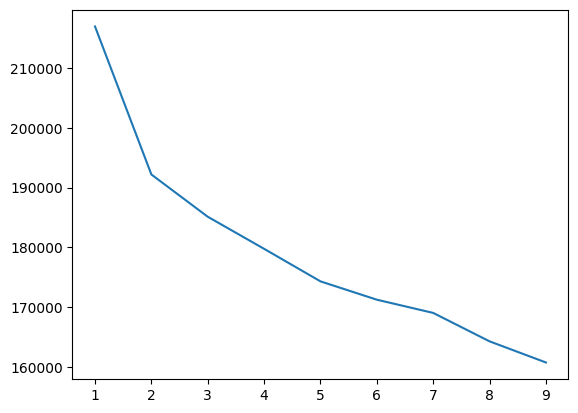

In [ ]:
y = np.array([i for i in range(1,10,1)])
plt.plot(y,custo);

In [ ]:
kmd = KModes(n_clusters=4, verbose=1)
kmd1 = kmd.fit_predict(df4)

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 6186, cost: 179774.0
Run 1, iteration: 2/100, moves: 1395, cost: 179774.0


In [ ]:
kmd1

array([1, 1, 0, ..., 0, 1, 0], shape=(41188,), dtype=uint16)

In [ ]:
kmd1[40000]

np.uint16(2)

In [ ]:
agrupamento = pd.DataFrame(kmd1, columns = ['grupo'])
agrupamento

,grupo
0,1
1,1
2,0
3,0
4,1
...,...
41183,0
41184,1
41185,0
41186,1


In [ ]:
df5 = pd.concat([df2, agrupamento],axis=1)

In [ ]:
df5.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,grupo
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,1


In [ ]:
df5.iloc[33284 , :]

age                             38
job                     technician
marital                    married
education      professional.course
default                         no
housing                         no
loan                            no
contact                   cellular
month                          may
day_of_week                    tue
poutcome               nonexistent
grupo                            0
Name: 33284, dtype: object

In [ ]:
grupo = df5.loc[df5.grupo == 3]
grupo.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,grupo
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,nonexistent,3
13,57,housemaid,divorced,basic.4y,no,yes,no,telephone,may,mon,nonexistent,3
28,54,technician,single,university.degree,unknown,no,no,telephone,may,mon,nonexistent,3
53,53,admin.,single,professional.course,no,no,no,telephone,may,mon,nonexistent,3
55,55,technician,married,professional.course,unknown,yes,no,telephone,may,mon,nonexistent,3


In [ ]:
grupo.shape

(3570, 12)

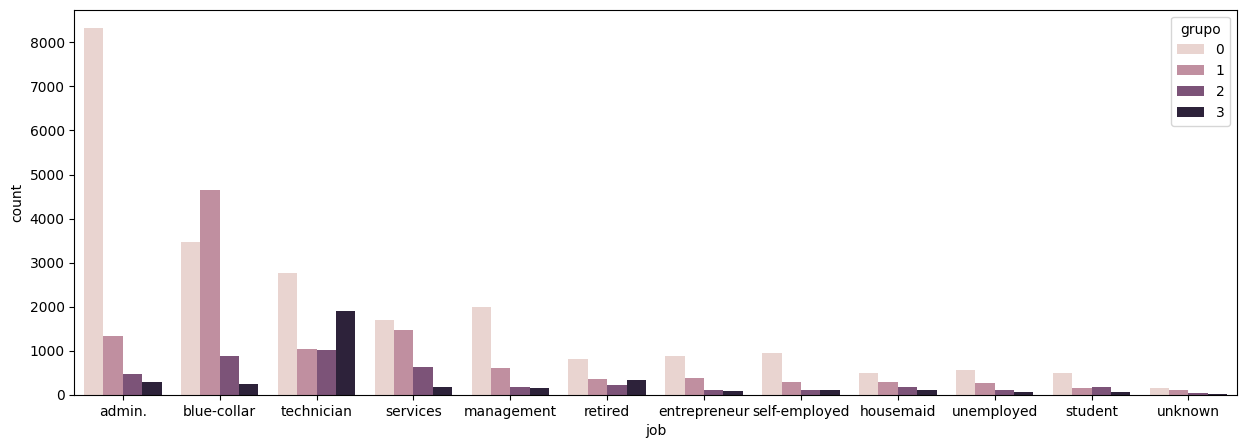

In [ ]:
plt.subplots(figsize = (15,5))
sns.countplot(x=df5['job'], order=df5['job'].value_counts().index, hue=df5['grupo'])
plt.show()